# **Random Forest**

## **Librerías**

In [19]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [20]:
from sklearn.metrics import *
from sklearn.ensemble import *
from sklearn.pipeline import *
from xgboost import XGBClassifier
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.feature_selection import *

## **Data**

In [21]:
df = pd.read_excel("../data/processed/df_to_model_frenel_21102025.xlsx")
df.head()

,target_tfg,pais_encuesta,grupo_origen,pais_nacimiento,edad,genero,grupo_etnico,nivel_escolaridad,regimen_salud,ocupacion,...,hacinamiento_hogar,hogar_migrantes,grupo_origen_ingles,ocupacion_agricola,imc,clasificacion_imc,grupo_edad,clasificacion_tfg,clasificacion_pa,creatinina_elevada
0,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,49,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,32.326531,Obesidad,41-50,Ligera (60-89),Hipertensión grado 2 (moderada),False
1,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,83,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador privado,Desempleado,...,NO,NO,AFRODESCENDANT,NO,22.206331,Normal,60+,Leve Moderada (45-59),Normal-alta,True
2,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,70,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,20.820940,Normal,60+,Ligera (60-89),Hipertensión grado 2 (moderada),False
3,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,25,Femenino,AFRODESCENDIENTE,Técnica,Asegurador público,Comerciante,...,SI,NO,AFRODESCENDANT,NO,23.738662,Normal,18-30,Ligera (60-89),Normal,True
4,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,64,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Desempleado,...,NO,NO,AFRODESCENDANT,NO,19.257029,Normal,60+,Leve Moderada (45-59),Normal,True


## **Preprocesamiento**

### **Selección de Variables**

In [22]:
data_modelo = df.drop(columns=['pais_encuesta', 'pais_nacimiento', 'ocupacion', 'georeferenciacion', 'grupo_origen_ingles', 'tasa_filtracion_glomerular'])
data_modelo_numericas= data_modelo.drop(columns = ['clasificacion_imc', 'grupo_edad', 'clasificacion_tfg', 'clasificacion_pa', 'creatinina_elevada', 'creatinina'])
data_modelo_categoricas = data_modelo.drop(columns = ['peso', 'grupo_edad', 'talla', 'presion_arterial_sistolica', 'presion_arterial_diastolica', 'creatinina', 'imc'])

### **Codificación Variables Categóricas**

In [23]:
cat_cols = data_modelo_numericas.select_dtypes(include=['object']).columns
num_cols = data_modelo_numericas.select_dtypes(include=['int64', 'float64']).columns
print("Categóricas:", len(cat_cols))
print("Numéricas:", len(num_cols))

Categóricas: 38
Numéricas: 7


In [24]:
df_encoded = pd.get_dummies(data_modelo_numericas, columns=cat_cols, drop_first=True)

## **Modelos**

### **Conjuntos de `Train` y `Test`**

In [25]:
X = df_encoded.drop('target_tfg', axis=1)
y = df_encoded['target_tfg']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [26]:
print(f' X_train.shape: {X_train.shape}\n X_test.shape: {X_test.shape}\n y_train.shape: {y_train.shape}\n y_test.shape: {y_test.shape}')

 X_train.shape: (3657, 64)
 X_test.shape: (1219, 64)
 y_train.shape: (3657,)
 y_test.shape: (1219,)


### **KBest**

In [27]:
select = SelectKBest(score_func=f_classif, k=25)
X_train_selected = select.fit_transform(X_train, y_train)
X_test_selected = select.transform(X_test)

**Variables seleccionadas por el `SelectKbest`:** con estas 25 variables se entrenará el modelo

In [28]:
F_values, p_values = f_classif(X, y)
feature_scores = pd.DataFrame({
    'Variable': X.columns,
    'F_value': F_values,
    'p_value': p_values,
    'Seleccionada': select.get_support()
})
feature_scores = feature_scores.sort_values(by='F_value', ascending=False)
print("\nVariables seleccionadas por SelectKBest:")
feature_scores[feature_scores['Seleccionada'] == True]


Variables seleccionadas por SelectKBest:


,Variable,F_value,p_value,Seleccionada
0,edad,333.387941,4.243896e-72,True
47,medicinas_presion_arterial_SI,230.862300,5.602328e-51,True
39,antecedentes_presion_alta_SI,214.708219,1.311539e-47,True
54,tirilla_reactiva_SI,132.651579,2.650115e-30,True
18,regimen_salud_Asegurador público,108.001861,4.895375e-25,True
43,antecedentes_enfermedad_circulatoria_SI,104.392127,2.910762e-24,True
19,regimen_salud_No asegurado,99.088428,4.008855e-23,True
44,medicinas_para_diabetes_SI,62.698312,2.961131e-15,True
40,paciente_diabetico_SI,60.016325,1.136820e-14,True
3,presion_arterial_sistolica,58.286667,2.709282e-14,True


### **Implementación Modelo**

In [29]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

In [30]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [31]:
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='recall',       # Optimizar Recall para reducir falsos negativos
    cv=5,# Validación cruzada (5 folds)
    n_jobs=-1,              # Usar todos los núcleos del CPU
    verbose=2
)

In [32]:
grid_search_rf.fit(X_train_selected, y_train)
best_rf = grid_search_rf.best_estimator_

print("Mejores Parámetros RF:", grid_search_rf.best_params_)
print("Mejor Recall en Validación Cruzada:", grid_search_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores Parámetros RF: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Mejor Recall en Validación Cruzada: 0.5235852500912742


### **Métricas y Resultados**

In [33]:
best_model = grid_search_rf.best_estimator_

In [34]:
y_train_pred = best_model.predict(X_train_selected)

recall_train = recall_score(y_train, y_train_pred)

print("MÉTRICAS EN TRAIN")
print("Recall Train:", recall_train)
print("\nReporte de Clasificación (Train):")
print(classification_report(y_train, y_train_pred))

MÉTRICAS EN TRAIN
Recall Train: 0.8082026537997588

Reporte de Clasificación (Train):
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2828
           1       0.69      0.81      0.75       829

    accuracy                           0.88      3657
   macro avg       0.82      0.85      0.83      3657
weighted avg       0.88      0.88      0.88      3657



In [35]:
y_test_pred = best_model.predict(X_test_selected)

print("MÉTRICAS EN TEST")
print("Recall Test:", recall_score(y_test, y_test_pred))
print("\nReporte de Clasificación (Test):")
print(classification_report(y_test, y_test_pred))


MÉTRICAS EN TEST
Recall Test: 0.5217391304347826

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       943
           1       0.48      0.52      0.50       276

    accuracy                           0.76      1219
   macro avg       0.67      0.68      0.67      1219
weighted avg       0.77      0.76      0.77      1219



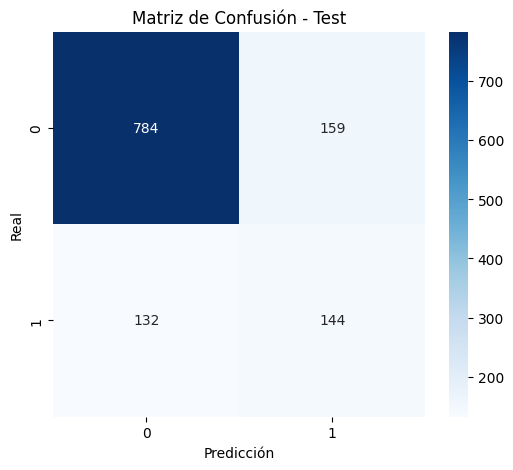

In [36]:
# Matriz de confusión - Test
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Paleta azul
plt.title("Matriz de Confusión - Test")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
